In [1]:
import pandas as pd
import numpy as np

## Exploring data

In [2]:
xls = pd.ExcelFile('cac40.xls')
df1 = pd.read_excel(xls, 'Poids', usecols=[0,2])
df2 = pd.read_excel(xls, 'Données quotidiennes', parse_dates=True).set_index("Date")
# Données Bloomberg same as données quotidiennes

In [3]:
df1.head()

,Valeurs,Poids dans l'indice
0,Accor SA,0.007442
1,Air Liquide SA,0.033058
2,Alcatel-Lucent/France,0.007738
3,Alstom SA,0.014156
4,ArcelorMittal,0.037576


##### dates range from 02-01-2001 to 09-03-2010

In [4]:
df2.head()

,CAC 40,Accor SA,Air Liquide,Alcatel-Lucent,Alstom,Arcelor Mittal,AXA SA,BNP Paribas,Bouygues,Cap Gemini SA,...,Societe Generale,STMicroelectronics NV,Suez SA,Total SA,Unibail-Rodamco,Vallourec,Veolia Environnement,Vinci SA,Vivendi,Tecnip
Date,,,,,,,,,,,,,,,,,,,,,
2001-01-02,5798.90,40.6441,51.4233,57.50,243.4292,2.75,37.6608,46.2384,41.0608,168.5,...,61.0437,42.59,NaN,39.0814,44.4303,10.8684,45.2226,16.4820,68.0,35.6527
2001-01-03,5684.05,41.0413,51.0560,54.50,247.4619,2.84,37.1290,45.3454,40.2027,158.0,...,60.4393,40.10,NaN,38.7113,44.6932,10.5093,45.2226,16.0770,67.5,36.8572
2001-01-04,5815.99,43.2919,52.4251,62.30,244.7124,3.20,37.0565,46.9330,45.9092,166.0,...,65.0885,45.20,NaN,37.9218,44.4303,10.5772,40.9435,15.4634,70.6,34.8818
2001-01-05,5758.02,44.0674,52.7590,61.65,241.8711,3.10,35.7270,47.4539,46.3383,166.9,...,65.0885,44.25,NaN,37.9958,44.7195,10.4802,41.5756,16.2979,70.7,35.8936
2001-01-08,5732.80,44.5402,53.3934,61.45,229.1314,3.10,35.3161,47.1314,43.7639,166.9,...,66.7622,43.40,NaN,38.4646,44.9298,10.6258,42.6940,15.7947,70.1,36.5922


##### Suez has become publicaly traded since 2008 (no data before). 

In [5]:
print("NaNs count")
df2.isna().sum(axis=0)

NaNs count


CAC 40                                    0
Accor SA                                  0
Air Liquide                               0
Alcatel-Lucent                            0
Alstom                                    0
Arcelor Mittal                            0
AXA SA                                    0
BNP Paribas                               0
Bouygues                                  0
Cap Gemini SA                             0
Carrefour SA                              0
Credit Agricole SA                      247
Groupe Danone                             0
Dexia SA                                  0
EADS                                      0
Electricite de France                  1273
Essilor International SA                  0
France Telecom SA                         0
Gaz de France SA                       1177
L'Oreal SA                                0
Lafarge SA                                0
Lagardere SCA                             0
LVMH Moet Hennessy Louis Vuitton

In [6]:
df2[["Gaz de France SA", "Electricite de France", "Suez SA"]].loc["2006":"2008"]

,Gaz de France SA,Electricite de France,Suez SA
Date,,,
2006-01-02,24.820,32.100,NaN
2006-01-03,25.600,32.360,NaN
2006-01-04,25.910,33.370,NaN
2006-01-05,25.650,33.290,NaN
2006-01-06,25.740,33.300,NaN
...,...,...,...
2008-12-25,32.785,40.240,11.600
2008-12-26,32.785,40.240,11.600
2008-12-29,33.745,40.005,11.240


## Final data

#####  We chose the period from 01-01-2006 to 31-12-2008 to do our study (GFC). We drop Suez SA stock.

In [7]:
data = df2.loc["2006":"2008"]
CAC0 = data["CAC 40"].iloc[0] # Used in reconstruction (for comparaison purpose)
CAC_data = data[["CAC 40"]]
data = data.drop(columns=["CAC 40","Suez SA"])
data.head()

,Accor SA,Air Liquide,Alcatel-Lucent,Alstom,Arcelor Mittal,AXA SA,BNP Paribas,Bouygues,Cap Gemini SA,Carrefour SA,...,Schneider Electric SA,Societe Generale,STMicroelectronics NV,Total SA,Unibail-Rodamco,Vallourec,Veolia Environnement,Vinci SA,Vivendi,Tecnip
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-02,44.6603,67.6860,10.70,24.365,23.27,27.0831,68.0677,41.19,34.12,39.85,...,74.9848,96.2380,15.24,52.7501,113.2,92.4017,37.8270,35.7130,26.60,49.8656
2006-01-03,45.1269,69.1736,10.67,24.550,22.50,27.1027,68.4149,40.86,34.38,40.27,...,74.5888,96.5169,15.34,53.1695,115.1,92.6966,38.3973,36.0321,26.39,50.5401
2006-01-04,45.8506,69.2975,10.98,26.600,22.52,27.7795,70.0521,41.12,35.35,40.99,...,77.1131,98.5626,15.55,52.9968,116.0,93.3847,38.7415,35.9830,26.64,51.6964
2006-01-05,45.4221,68.8843,11.17,26.300,22.23,27.7010,69.8537,41.53,37.56,40.88,...,76.9151,98.4696,15.75,52.8734,117.1,92.8146,38.3383,35.0257,26.47,51.2628
2006-01-06,46.6695,69.0083,11.45,27.000,22.40,27.8972,70.0025,42.68,38.27,41.22,...,77.4100,99.3994,16.19,53.5396,117.0,92.0675,38.1220,35.2221,26.49,51.8409


In [8]:
data.isna().sum()

Accor SA                               0
Air Liquide                            0
Alcatel-Lucent                         0
Alstom                                 0
Arcelor Mittal                         0
AXA SA                                 0
BNP Paribas                            0
Bouygues                               0
Cap Gemini SA                          0
Carrefour SA                           0
Credit Agricole SA                     0
Groupe Danone                          0
Dexia SA                               0
EADS                                   0
Electricite de France                  0
Essilor International SA               0
France Telecom SA                      0
Gaz de France SA                       0
L'Oreal SA                             0
Lafarge SA                             0
Lagardere SCA                          0
LVMH Moet Hennessy Louis Vuitton SA    0
Michelin                               0
Pernod-Ricard SA                       0
Peugeot SA      

### Comments :

The Data frame on which we will work doesn't contain any missing values!

In [9]:
poids = df1[df1["Valeurs"]!="GDF Suez"]["Poids dans l'indice"]

## Log returns

In [10]:
returns = np.log(data).diff().dropna()
returns.head()

,Accor SA,Air Liquide,Alcatel-Lucent,Alstom,Arcelor Mittal,AXA SA,BNP Paribas,Bouygues,Cap Gemini SA,Carrefour SA,...,Schneider Electric SA,Societe Generale,STMicroelectronics NV,Total SA,Unibail-Rodamco,Vallourec,Veolia Environnement,Vinci SA,Vivendi,Tecnip
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-03,0.010394,0.021740,-0.002808,0.007564,-0.033650,0.000723,0.005088,-0.008044,0.007591,0.010484,...,-0.005295,0.002894,0.006540,0.007919,0.016645,0.003186,0.014964,0.008895,-0.007926,0.013436
2006-01-04,0.015910,0.001790,0.028639,0.080199,0.000888,0.024665,0.023649,0.006343,0.027823,0.017721,...,0.033283,0.020974,0.013597,-0.003253,0.007789,0.007396,0.008924,-0.001364,0.009429,0.022621
2006-01-05,-0.009390,-0.005981,0.017156,-0.011342,-0.012961,-0.002830,-0.002836,0.009921,0.060641,-0.002687,...,-0.002571,-0.000944,0.012780,-0.002331,0.009438,-0.006124,-0.010462,-0.026965,-0.006402,-0.008423
2006-01-06,0.027092,0.001799,0.024758,0.026268,0.007618,0.007058,0.002128,0.027314,0.018727,0.008283,...,0.006414,0.009398,0.027553,0.012521,-0.000854,-0.008082,-0.005658,0.005592,0.000755,0.011214
2006-01-09,0.015388,-0.010837,0.005226,0.001850,0.050065,-0.017020,0.007767,0.009328,-0.008133,0.000000,...,-0.003843,-0.003748,0.008610,0.008261,-0.006861,0.000641,-0.011935,-0.008399,0.005647,0.001858


## Stationnarité 

In [11]:
from statsmodels.tsa.stattools import adfuller

In [12]:
for i in range(returns.shape[1]):
    result = adfuller(returns.iloc[:,i])
    print(f"p-value for {returns.columns[i]}: {result[1]}")

p-value for Accor SA: 0.0
p-value for Air Liquide: 3.9746629543549724e-24
p-value for Alcatel-Lucent: 6.482346358302943e-09
p-value for Alstom: 1.380063576512553e-07
p-value for Arcelor Mittal: 2.1894500388055377e-05
p-value for AXA SA: 9.83065289004905e-09
p-value for BNP Paribas: 7.600792627315289e-14
p-value for Bouygues: 2.4544008725004863e-27
p-value for Cap Gemini SA: 0.0
p-value for Carrefour SA: 1.1214723678724573e-14
p-value for Credit Agricole SA: 3.7056906177120926e-12
p-value for Groupe Danone: 4.4803379769758464e-27
p-value for Dexia SA: 2.7703668239211738e-30
p-value for EADS: 7.825551466381352e-30
p-value for Electricite de France: 0.0
p-value for Essilor International SA: 1.1021307628504604e-16
p-value for France Telecom SA: 1.2750456214463292e-13
p-value for Gaz de France SA: 1.368260878180523e-13
p-value for L'Oreal SA: 1.1853683927684665e-25
p-value for Lafarge SA: 0.0
p-value for Lagardere SCA: 4.541456554759308e-12
p-value for LVMH Moet Hennessy Louis Vuitton SA: 3

Based on the p-values, which are all below 5% or even 1%, we can conclude that we lack enough evidence to reject the null hypothesis that the data is not stationary, with a 99% confidence level.

## Normalisation

In [13]:
# Mean of each stock returns
returns.describe().loc["mean",:]

Accor SA                              -0.000308
Air Liquide                           -0.000043
Alcatel-Lucent                        -0.002485
Alstom                                 0.000696
Arcelor Mittal                        -0.000401
AXA SA                                -0.000685
BNP Paribas                           -0.001037
Bouygues                              -0.000397
Cap Gemini SA                         -0.000276
Carrefour SA                          -0.000473
Credit Agricole SA                    -0.001426
Groupe Danone                         -0.000039
Dexia SA                              -0.002327
EADS                                  -0.001249
Electricite de France                  0.000328
Essilor International SA              -0.000030
France Telecom SA                     -0.000078
Gaz de France SA                       0.000451
L'Oreal SA                            -0.000021
Lafarge SA                            -0.000726
Lagardere SCA                         -0

In [14]:
# volatility of each stock
returns.describe().loc["std",:]

Accor SA                               0.022032
Air Liquide                            0.016599
Alcatel-Lucent                         0.030616
Alstom                                 0.030322
Arcelor Mittal                         0.034565
AXA SA                                 0.029454
BNP Paribas                            0.025521
Bouygues                               0.024628
Cap Gemini SA                          0.025381
Carrefour SA                           0.019682
Credit Agricole SA                     0.029526
Groupe Danone                          0.017356
Dexia SA                               0.034072
EADS                                   0.029297
Electricite de France                  0.021685
Essilor International SA               0.015602
France Telecom SA                      0.017100
Gaz de France SA                       0.022875
L'Oreal SA                             0.017923
Lafarge SA                             0.023478
Lagardere SCA                          0

***Normalisation:*** 

Based on the previous observation, we can see that the mean returns for all the stocks are centered around zero, and the levels of volatility are almost identical. Consequently, we have made the decision not to normalize the data.

## Gaussianity of the returns

In [15]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

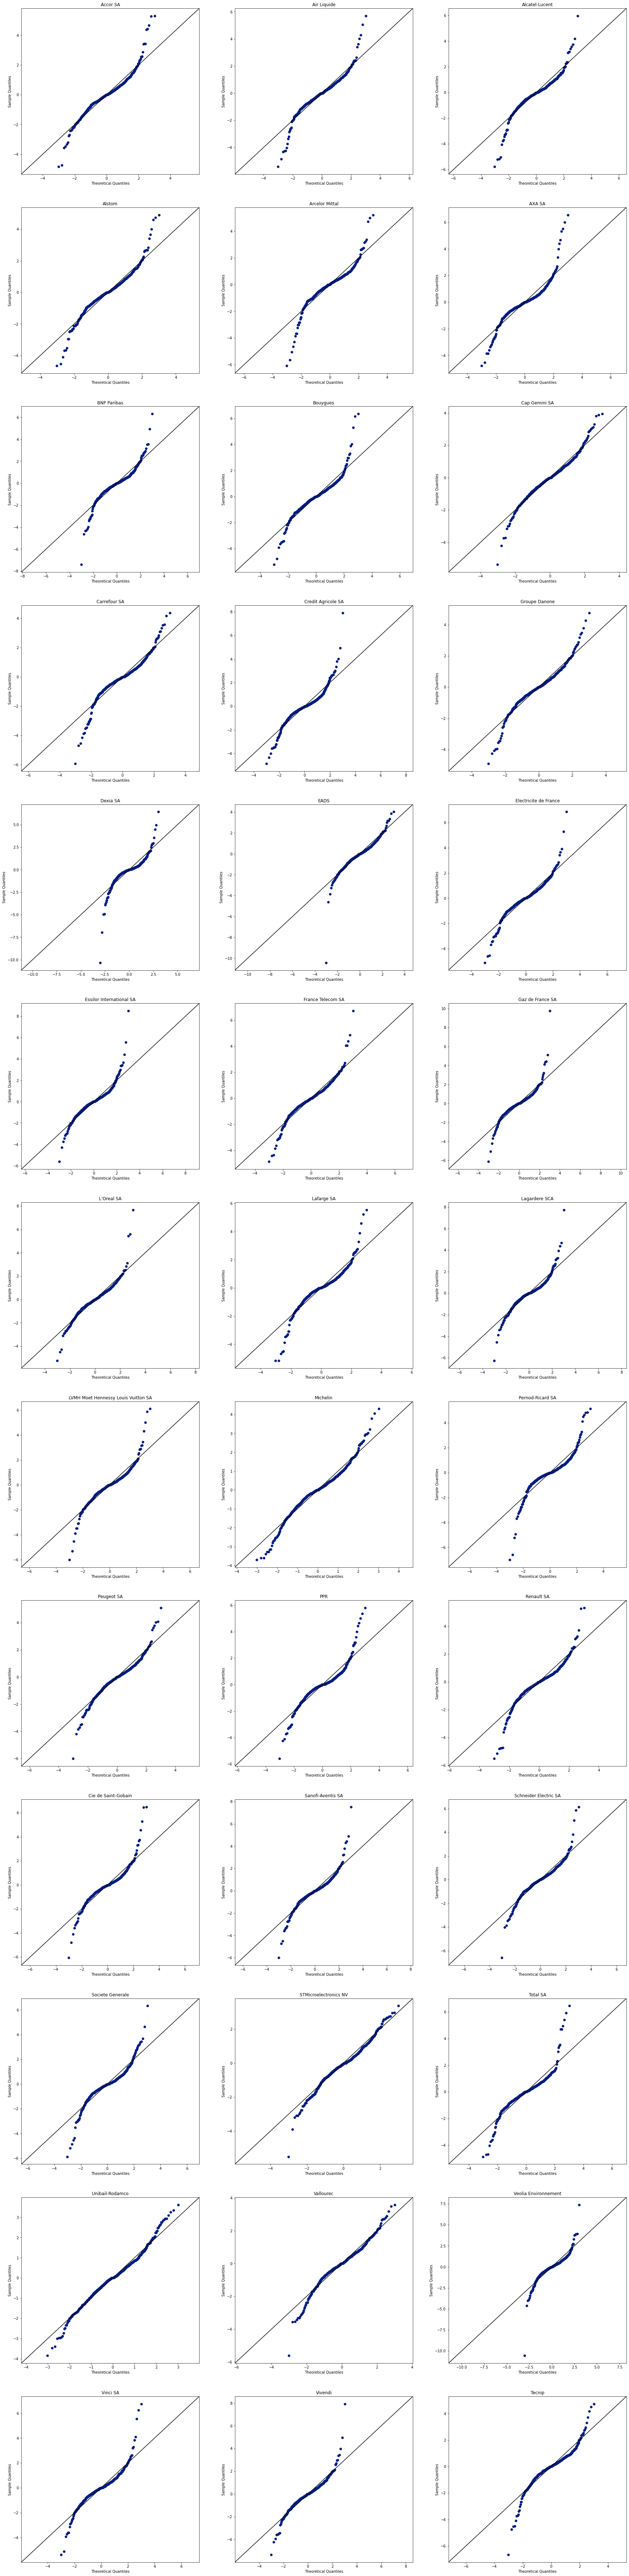

In [16]:
with plt.style.context('seaborn-dark-palette'):
    fig, ax = plt.subplots(figsize=(30, 130), ncols=3, nrows=13)
    for i, row in enumerate(ax):
        for j, col in enumerate(row):
            idx = 3*i + j
            if idx < len(returns.columns):
                sm.qqplot(returns.iloc[:, idx] / returns.iloc[:, idx].std(), line='45', ax=col)
                col.get_lines()[1].set_color("black")
                col.set_title(returns.columns[idx])
        

    plt.show()

It is evident from the qqplots illustrated above that the distribution of returns does not match up to the Gaussian distribution.

## ICA

In [17]:
import jadeR

In [18]:
W = jadeR.jadeR(returns.values.T, verbose=True)

jade -> Looking for 39 sources
jade -> Removing the mean value
jade -> Whitening the data
jade -> Estimating cumulant matrices
jade -> Contrast optimization by joint diagonalization
jade -> Sweep #  0
completed in 741 rotations
jade -> Sweep #  1
completed in 741 rotations
jade -> Sweep #  2
completed in 741 rotations
jade -> Sweep #  3
completed in 741 rotations
jade -> Sweep #  4
completed in 741 rotations
jade -> Sweep #  5
completed in 741 rotations
jade -> Sweep #  6
completed in 741 rotations
jade -> Sweep #  7
completed in 741 rotations
jade -> Sweep #  8
completed in 741 rotations
jade -> Sweep #  9
completed in 740 rotations
jade -> Sweep # 10
completed in 740 rotations
jade -> Sweep # 11
completed in 741 rotations
jade -> Sweep # 12
completed in 740 rotations
jade -> Sweep # 13
completed in 741 rotations
jade -> Sweep # 14
completed in 741 rotations
jade -> Sweep # 15
completed in 741 rotations
jade -> Sweep # 16
completed in 738 rotations
jade -> Sweep # 17
completed in 737 

In [19]:
ICs = W@(returns.values.T)

In [20]:
ICs.shape

(39, 782)

In [21]:
df_ICs = pd.DataFrame(ICs.T, columns=[f"IC{i}" for i in range(1,40)])
df_ICs.index = returns.index

In [22]:
df_ICs.head()

,IC1,IC2,IC3,IC4,IC5,IC6,IC7,IC8,IC9,IC10,...,IC30,IC31,IC32,IC33,IC34,IC35,IC36,IC37,IC38,IC39
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-03,-0.038335,-1.022945,0.175933,0.743106,-1.480187,-0.778813,0.338272,-0.872971,-1.280023,-1.008214,...,-0.033084,1.102613,-0.802483,0.994089,-0.715373,0.157250,0.860813,-0.416880,0.960535,-0.059820
2006-01-04,0.827514,0.303812,0.605983,-0.433880,-1.541420,2.043741,-0.363071,0.688367,-1.236420,-0.259361,...,-1.049132,-0.220441,0.936182,2.101145,0.444246,-0.345471,0.759925,-0.817781,0.220312,-0.071677
2006-01-05,-1.075451,-0.601668,0.200728,-1.006338,-0.406060,1.121322,0.716280,1.616368,0.004670,-0.075883,...,-0.720672,0.344959,1.051307,-1.528178,-1.294164,1.309331,0.262182,0.945151,-0.543047,-0.914336
2006-01-06,-0.162402,0.722683,-0.085721,-0.406715,-0.111199,-0.163225,1.604804,0.984321,0.230404,0.005486,...,0.531008,0.931761,-0.253847,0.572620,0.394110,-0.151250,0.641482,0.646552,-0.557183,-0.297434
2006-01-09,-0.794451,0.564178,-1.459207,0.390003,0.634553,0.594375,0.216513,0.447677,0.922961,0.174303,...,0.869965,-1.320436,1.279277,0.019064,0.288466,-1.196356,0.640161,1.905409,0.627648,1.157436


## PCA

In [23]:
from numpy.linalg import svd

In [24]:
u, s, v = svd(returns.values)

In [25]:
PCs = v@(returns.values.T)

In [26]:
PCs.shape

(39, 782)

In [27]:
df_PCs = pd.DataFrame(PCs.T, columns=[f"PC{i}" for i in range(1,40)])
df_PCs.index = returns.index

In [28]:
df_PCs.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC30,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39
Date,,,,,,,,,,,,,,,,,,,,,
2006-01-03,-0.023096,0.000821,-0.019816,0.003682,0.004291,-0.012955,0.006781,-0.019568,-0.025475,-0.002728,...,-0.008213,0.001130,-0.000230,0.001332,-0.013798,0.007458,0.000694,0.016777,-0.004708,0.014830
2006-01-04,-0.076353,0.003666,0.006987,0.018372,0.016347,0.018579,0.009655,0.019051,-0.023747,0.005163,...,0.006179,-0.003355,0.003900,0.001215,0.015088,-0.021927,0.000694,-0.004739,-0.002903,0.014637
2006-01-05,0.005091,-0.019363,-0.012618,-0.003666,-0.008782,-0.000582,0.012767,0.037503,-0.016246,-0.009202,...,0.016335,-0.006573,-0.008911,0.027526,0.005200,0.001699,0.003689,0.004103,-0.004808,-0.000106
2006-01-06,-0.045595,0.004846,-0.009020,0.008528,-0.010406,0.009850,0.009562,0.013752,-0.005801,0.006478,...,-0.004140,0.010838,-0.013116,0.017781,0.005144,-0.001048,0.002816,0.000353,-0.003834,-0.001913
2006-01-09,-0.023863,0.019470,0.010124,0.017112,-0.017773,0.003204,0.009080,0.001733,0.032990,0.010065,...,0.012485,0.003438,0.018369,-0.001214,-0.005900,-0.006485,-0.000800,-0.000422,0.014717,-0.009669


## Reconstructing CAC40

In [29]:
from numpy.linalg import inv

We will reconstruct the returns using the most dominant principal components and the most dominant independent components and then calculates the CAC 40. We will then compare the results in a graph to see if the reconstructed signal reproduce the stylized facts of the original one.

In [30]:
def Reconstructing_ICs(df_ICs, poids, W, number_components=5, CAC0=CAC0):
    df = df_ICs.copy()
    DICs = df.describe().loc["max"].sort_values(ascending=False).index[:number_components].to_list() # Dominant components
    df[list(set(df.columns)-set(DICs))] = 0
    returns_DICs = (inv(W)@(df.T)).T
    returns_DICs.columns = returns.columns
    CAC40_DICs = returns_DICs@poids.to_numpy().reshape((-1,1))
    CAC40_DICs.columns = [f"CAC 40 with {number_components} most dominant ICs"]
    return (CAC40_DICs+1).cumprod()*CAC0

In [31]:
def Reconstructing_PCs(df_PCs, poids, v, number_components=5, CAC0=CAC0):
    df = df_PCs.copy()
    DIPs = df.describe().loc["max"].sort_values(ascending=False).index[:number_components].to_list() # Dominant components
    df[list(set(df.columns)-set(DIPs))] = 0
    returns_DIPs = (inv(v)@(df.T)).T
    returns_DIPs.columns = returns.columns
    CAC40_DIPs = returns_DIPs@poids.to_numpy().reshape((-1,1))
    CAC40_DIPs.columns = [f"CAC 40 with {number_components} most dominant PCs"]
    return (CAC40_DIPs+1).cumprod()*CAC0

In [32]:
def Reconstructing_PCs_variance(df_PCs, poids, v, number_components=5, CAC0=CAC0):
    df = df_PCs.copy()
    DIPs = df.columns[:number_components] # Dominant components
    df[list(set(df.columns)-set(DIPs))] = 0
    returns_DIPs = (inv(v)@(df.T)).T
    returns_DIPs.columns = returns.columns
    CAC40_DIPs = returns_DIPs@poids.to_numpy().reshape((-1,1))
    CAC40_DIPs.columns = [f"CAC 40 with {number_components} most dominant PCs"]
    return (CAC40_DIPs+1).cumprod()*CAC0

In [33]:
CAC40_DICs = Reconstructing_ICs(df_ICs, poids, W, 10)
CAC40_DIPs = Reconstructing_PCs(df_PCs, poids, v, 10)

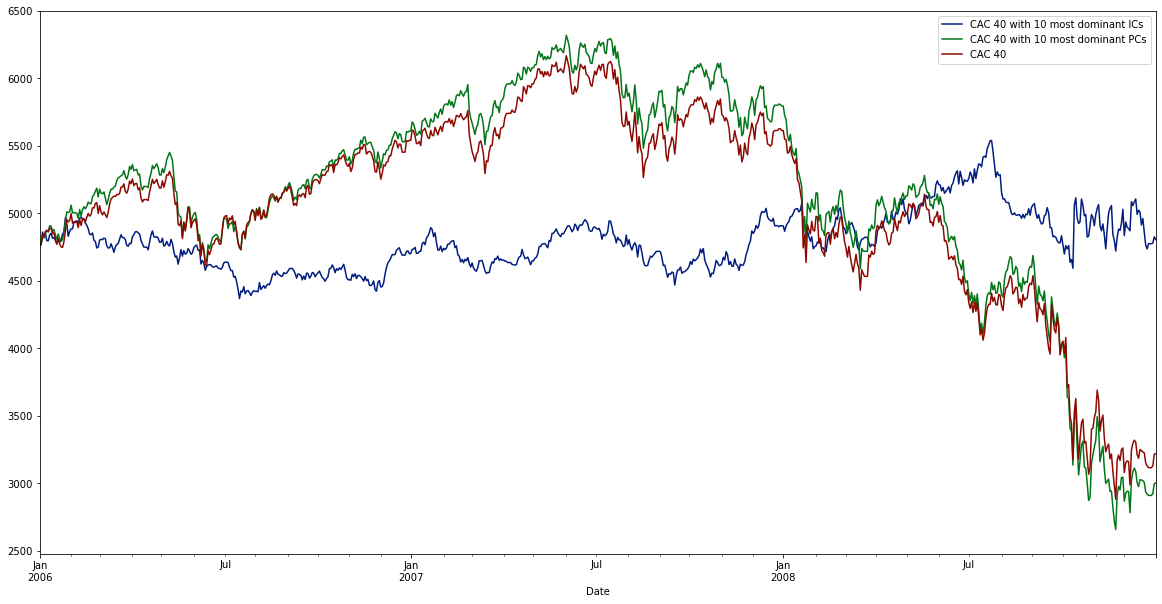

In [34]:
with plt.style.context('seaborn-dark-palette'):

    fig, ax = plt.subplots(figsize=(20,10), ncols=1, nrows=1)

    CAC40_DICs.plot(ax=ax)
    CAC40_DIPs.plot(ax=ax)
    CAC_data.plot(ax=ax)

    plt.show()

### Comments:

From the previous graph, it is obvious that the top 10 dominant principal components exhibit a clear correlation with the trend of the CAC40, they reproduce almost the same stylized facts. However, the same cannot be said for the top 5 dominant independent components.